<a href="https://colab.research.google.com/github/Adhithyan6/Deep-Learning-Techniques/blob/master/Autoencoder/Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 10: Train Loss = 0.013553, Val Loss = 0.013276
Epoch 20: Train Loss = 0.010141, Val Loss = 0.009889
Epoch 30: Train Loss = 0.008748, Val Loss = 0.008650
Epoch 40: Train Loss = 0.008040, Val Loss = 0.007860
Epoch 50: Train Loss = 0.007539, Val Loss = 0.007571
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Original shape: (60000, 784)
Compressed shape: (60000, 32)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Reconstruction Error (MSE): 0.007571


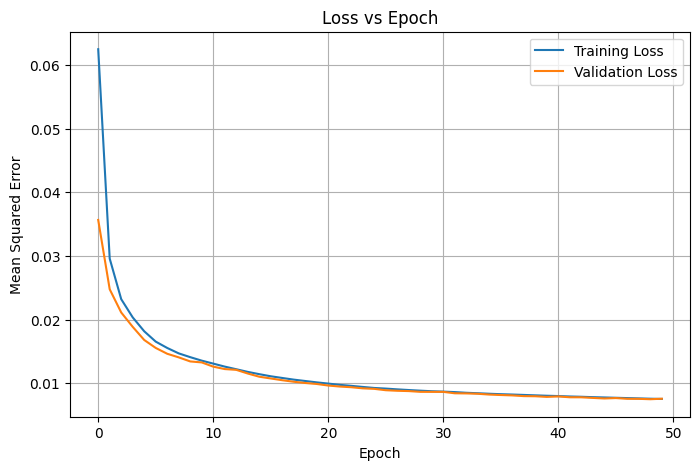

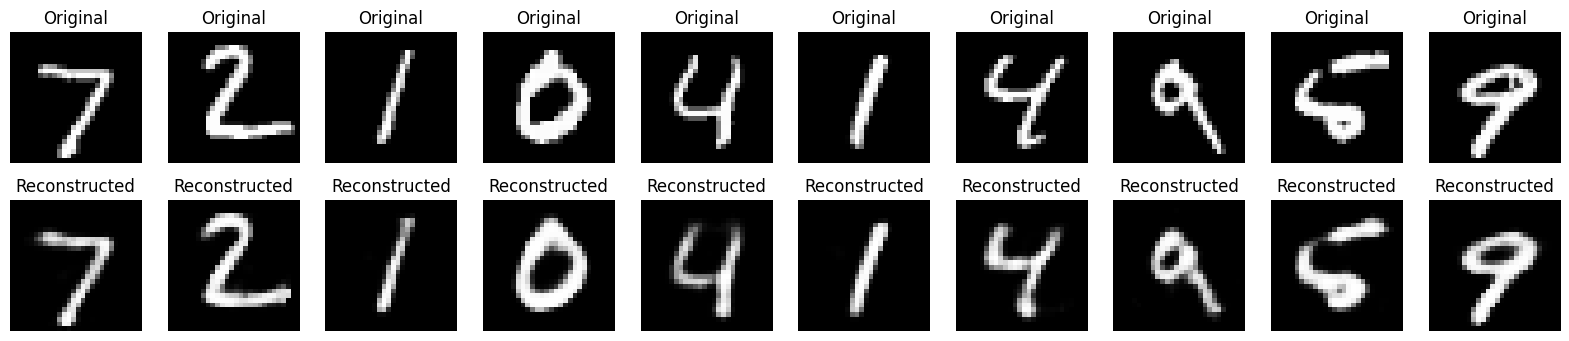

In [ ]:
# Step 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback

# Step 2: Load the MNIST dataset
(X_train, _), (X_test, _) = mnist.load_data()

# Step 3: Normalize pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Step 4: Flatten images (28x28 → 784)
X_train = X_train.reshape((len(X_train), 28 * 28))
X_test = X_test.reshape((len(X_test), 28 * 28))

# Step 5: Custom callback to print losses every 10 epochs
class PrintLossEvery10(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            train_loss = logs.get('loss')
            val_loss = logs.get('val_loss')
            print(f"Epoch {epoch + 1:02d}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

# Step 6: Define Autoencoder architecture
input_dim = 784

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
bottleneck = Dense(32, activation='relu')(encoded)  # compressed representation

# Decoder
decoded = Dense(64, activation='relu')(bottleneck)
decoded = Dense(128, activation='relu')(decoded)
output_layer = Dense(784, activation='sigmoid')(decoded)

# Step 7: Connect Encoder and Decoder
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Step 8: Compile the Autoencoder
autoencoder.compile(optimizer=Adam(), loss='mean_squared_error')

# Step 9: Train the Autoencoder with callback
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=0,
    callbacks=[PrintLossEvery10()]  # print losses every 10 epochs
)

# Step 10: Extract Encoder for compression
encoder = Model(inputs=input_layer, outputs=bottleneck)

# Step 11: Perform compression
compressed_train = encoder.predict(X_train)
compressed_test = encoder.predict(X_test)

print("\nOriginal shape:", X_train.shape)
print("Compressed shape:", compressed_train.shape)

# Step 12: Reconstruct images (optional)
reconstructed = autoencoder.predict(X_test)

# Step 13: Evaluate compression
mse = np.mean(np.square(X_test - reconstructed))
print(f"\nReconstruction Error (MSE): {mse:.6f}")

# Step 14: Plot Loss vs Epoch graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# Step 15: Visualize few original vs reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()
